In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Multiply, Activation, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
df = pd.read_csv('D:\study\semster 2 year 3\XAI\XAI github\cardiovascular_fe.csv')
df.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
0,50,2,168,62,110,80,1,1,0,0,1,0,21.967120,30,90.000000,50,2,5500
1,55,1,156,85,140,90,3,1,0,0,1,1,34.927679,50,106.666667,165,4,7700
2,52,1,165,64,130,70,3,1,0,0,0,1,23.507805,60,90.000000,156,4,6760
3,48,2,169,82,150,100,1,1,0,0,1,1,28.710479,50,116.666667,48,2,7200
4,60,1,151,67,120,80,2,2,0,0,0,0,29.384676,40,93.333333,120,4,7200


In [34]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 62513 entries, 0 to 62512
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AGE                62513 non-null  int64  
 1   GENDER             62513 non-null  int64  
 2   HEIGHT             62513 non-null  int64  
 3   WEIGHT             62513 non-null  int64  
 4   AP_HIGH            62513 non-null  int64  
 5   AP_LOW             62513 non-null  int64  
 6   CHOLESTEROL        62513 non-null  int64  
 7   GLUCOSE            62513 non-null  int64  
 8   SMOKE              62513 non-null  int64  
 9   ALCOHOL            62513 non-null  int64  
 10  PHYSICAL_ACTIVITY  62513 non-null  int64  
 11  CARDIO_DISEASE     62513 non-null  int64  
 12  BMI                62513 non-null  float64
 13  PULSE_PRESSURE     62513 non-null  int64  
 14  MAP                62513 non-null  float64
 15  RISK_SCORE         62513 non-null  int64  
 16  METABOLIC_RISK     62513 non-null

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
count,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000
mean,53.406028,1.348583,164.405964,73.180474,126.419609,81.698367,1.357686,1.220610,0.086334,0.052165,0.804313,0.493881,27.119944,44.721242,96.605447,73.211412,2.578296,6771.354806
std,6.742440,0.476526,7.531095,12.272424,14.290546,7.673384,0.675167,0.567559,0.280859,0.222362,0.396732,0.499967,4.567853,10.409748,9.123951,39.917202,1.059672,1257.682992
min,30.000000,1.000000,143.000000,40.000000,90.000000,65.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,13.520822,-10.000000,73.333333,30.000000,2.000000,3300.000000
25%,49.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115,40.000000,93.333333,50.000000,2.000000,5880.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.233556,40.000000,93.333333,56.000000,2.000000,6720.000000
75%,58.000000,2.000000,170.000000,81.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,29.760838,50.000000,103.333333,64.000000,3.000000,7560.000000
max,65.000000,2.000000,186.000000,107.000000,170.000000,105.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,50.891795,103.000000,126.000000,195.000000,6.000000,11050.000000


In [35]:
df.isnull().sum()

AGE                  0
GENDER               0
HEIGHT               0
WEIGHT               0
AP_HIGH              0
AP_LOW               0
CHOLESTEROL          0
GLUCOSE              0
SMOKE                0
ALCOHOL              0
PHYSICAL_ACTIVITY    0
CARDIO_DISEASE       0
BMI                  0
PULSE_PRESSURE       0
MAP                  0
RISK_SCORE           0
METABOLIC_RISK       0
AGE_BP_RISK          0
dtype: int64

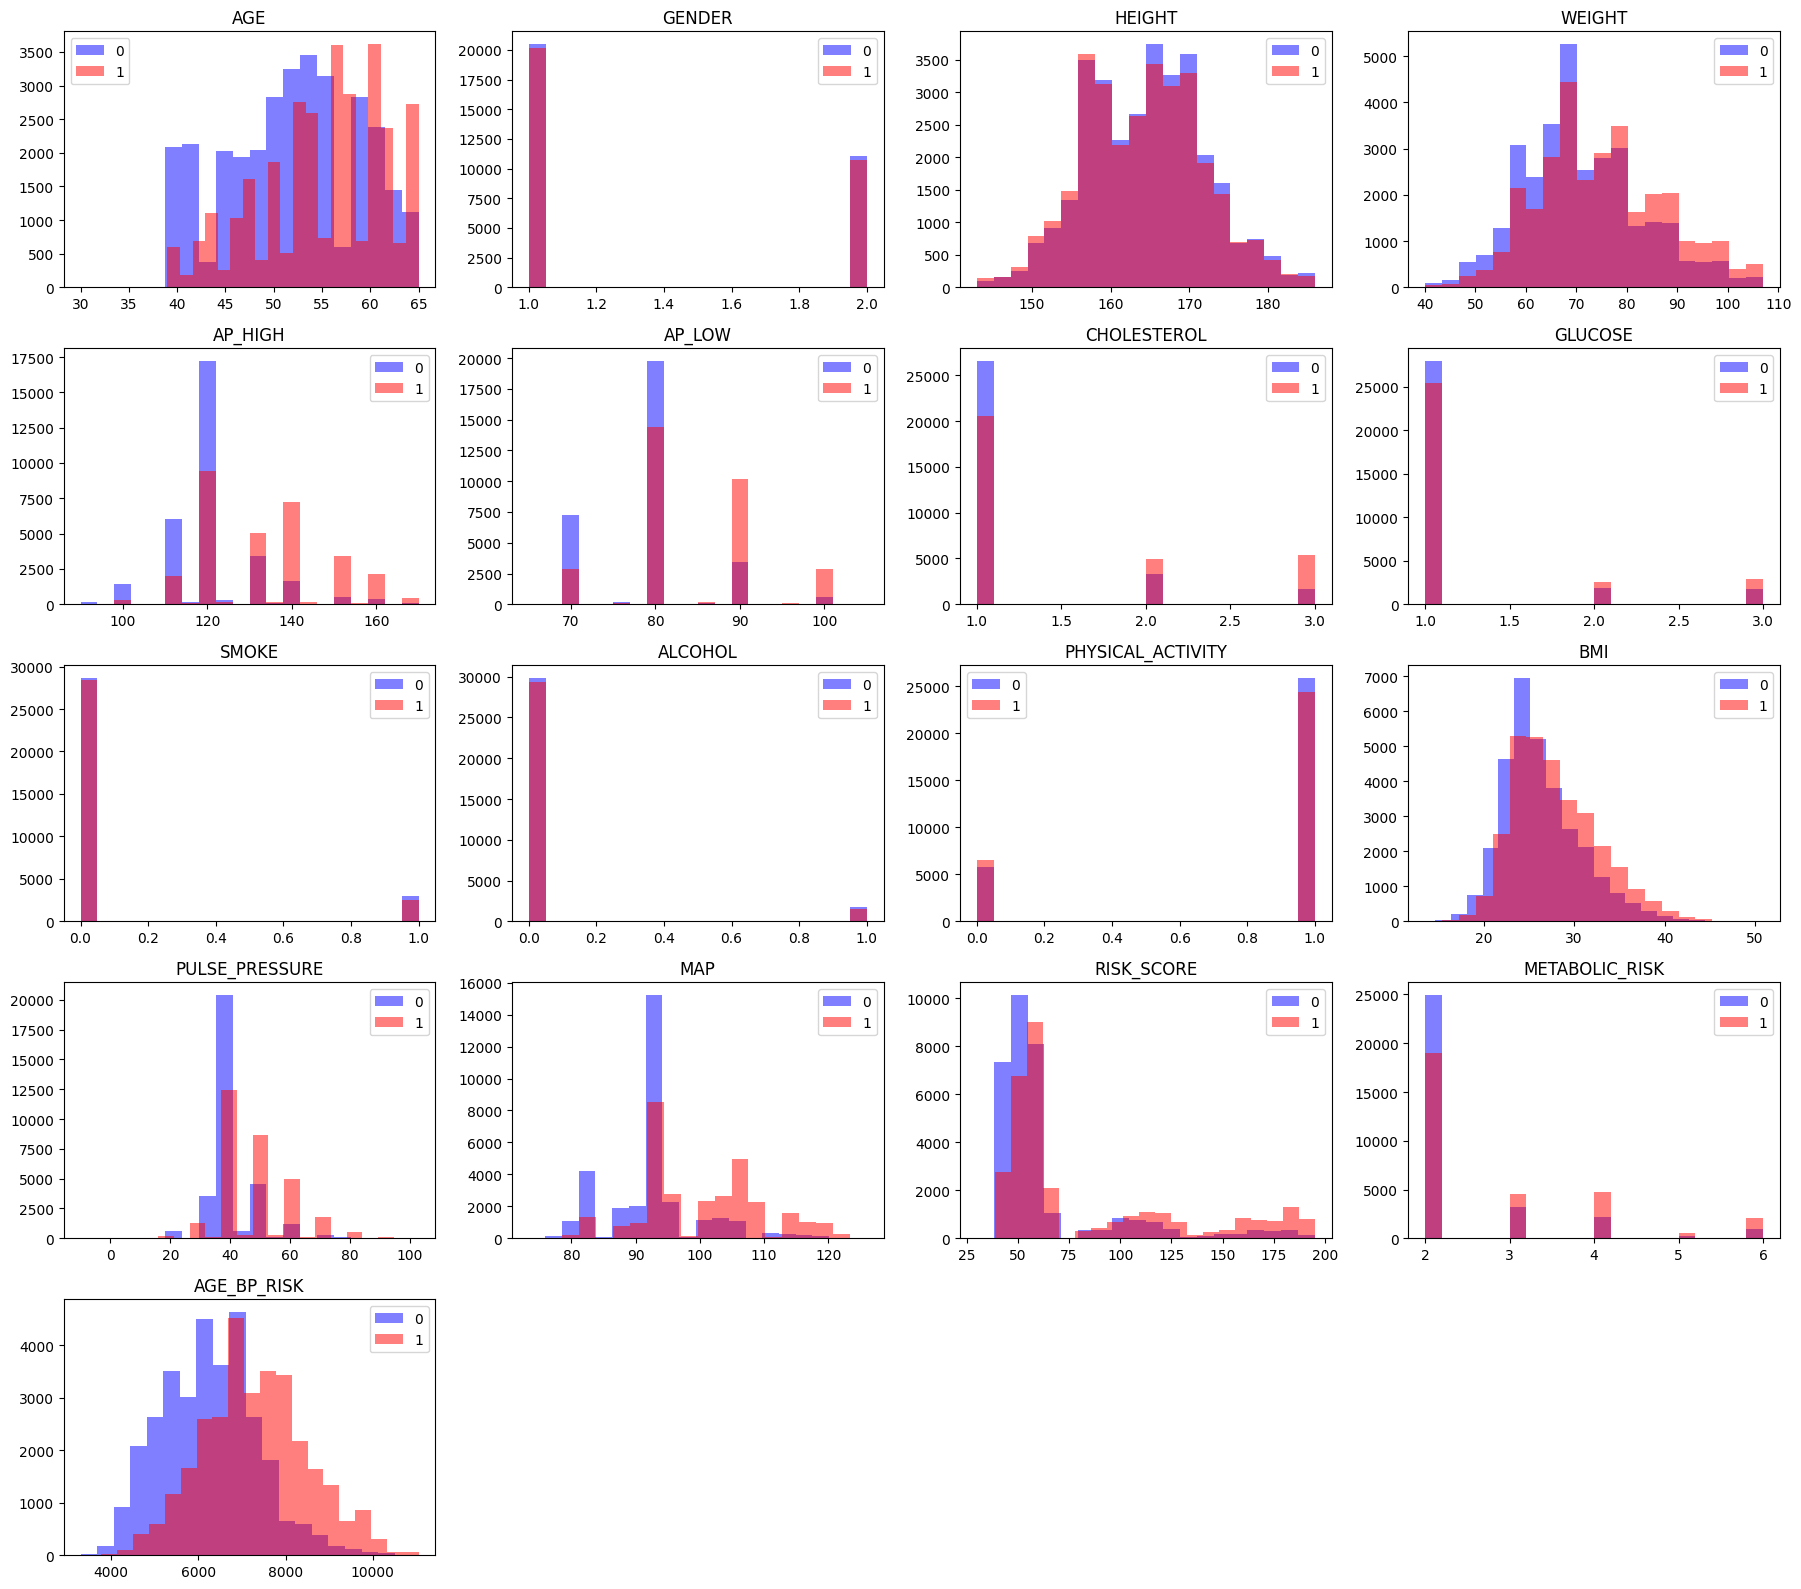

In [39]:
# Histograms per feature stratified by target
target_col = 'CARDIO_DISEASE'
num_features = [c for c in df.columns if c != target_col]

fig, axes = plt.subplots(5, 4, figsize=(18, 16))
axes = axes.flatten()
for i, feat in enumerate(num_features):
    for val, color in zip([0, 1], ['blue', 'red']):
        axes[i].hist(df[df[target_col] == val][feat], bins=20, alpha=0.5, color=color, label=str(val))
    axes[i].set_title(feat)
    axes[i].legend()
for ax in axes[len(num_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

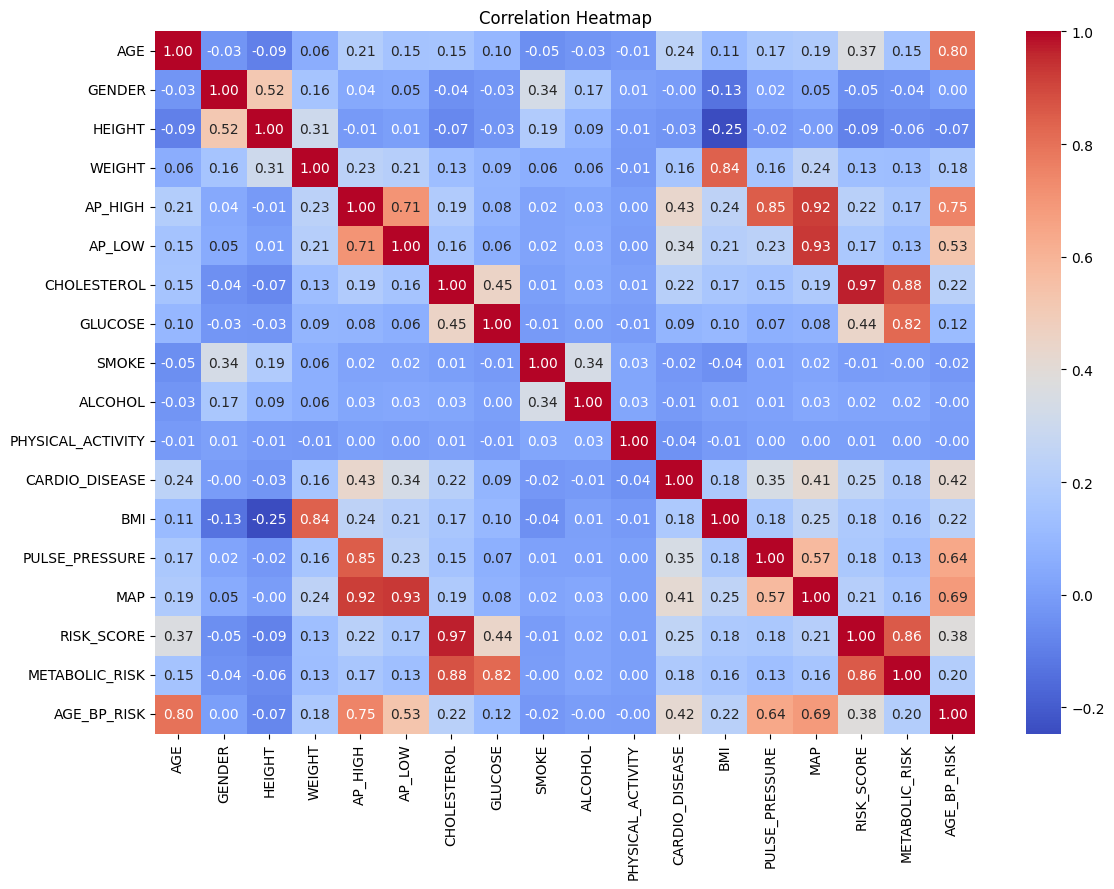

In [40]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

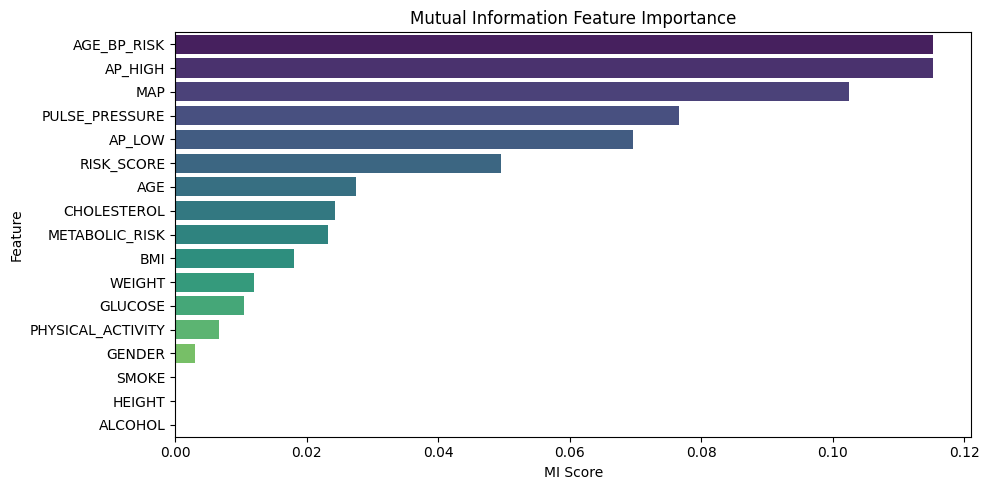

In [41]:
# Mutual Information
X= df.drop(target_col, axis=1)
y = df[target_col]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores}).sort_values('MI Score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=mi_df, x='MI Score', y='Feature', palette='viridis')
plt.title('Mutual Information Feature Importance')
plt.tight_layout()
plt.show()

In [42]:
# Min-Max normalization
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
feature_names = list(X.columns)

In [43]:
# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

Round 1 | Labeled: 50 | Test Acc: 0.6147
Round 2 | Labeled: 70 | Test Acc: 0.6245
Round 3 | Labeled: 90 | Test Acc: 0.6381
Round 4 | Labeled: 110 | Test Acc: 0.6378
Round 5 | Labeled: 130 | Test Acc: 0.6374


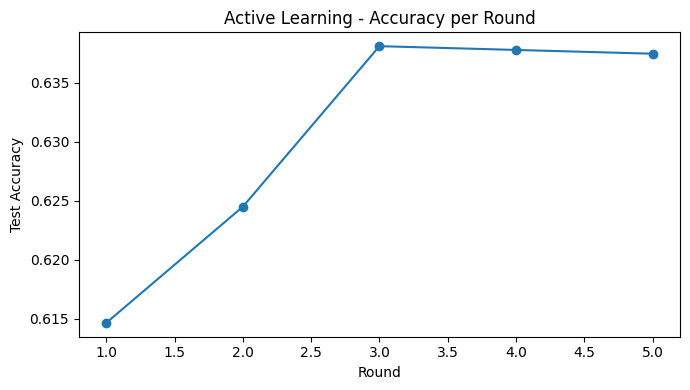

In [44]:
# Active Learning simulation (uncertainty sampling)
# Start with a small labeled pool, iteratively add uncertain samples

from sklearn.ensemble import RandomForestClassifier as RFC

n_initial = 50
n_query   = 20
n_rounds  = 5

all_idx = np.arange(len(X_train))
labeled_idx   = np.random.choice(all_idx, n_initial, replace=False)
unlabeled_idx = np.setdiff1d(all_idx, labeled_idx)

al_model = RFC(n_estimators=100, random_state=42)
al_accuracies = []

for r in range(n_rounds):
    al_model.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])
    acc = accuracy_score(y_test, al_model.predict(X_test))
    al_accuracies.append(acc)
    print(f'Round {r+1} | Labeled: {len(labeled_idx)} | Test Acc: {acc:.4f}')

    if len(unlabeled_idx) == 0:
        break
    proba = al_model.predict_proba(X_train[unlabeled_idx])
    uncertainty = 1 - proba.max(axis=1)
    query_idx = unlabeled_idx[np.argsort(uncertainty)[-n_query:]]
    labeled_idx   = np.concatenate([labeled_idx, query_idx])
    unlabeled_idx = np.setdiff1d(unlabeled_idx, query_idx)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(al_accuracies)+1), al_accuracies, marker='o')
plt.title('Active Learning - Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Test Accuracy')
plt.tight_layout()
plt.show()

In [45]:
# ---- MODEL 1: Attention-based Neural Network (CardioRiskNet style) ----

n_features = X_train.shape[1]

inp = Input(shape=(n_features,))

# Attention mechanism: learn a weight per feature
attn = Dense(n_features, activation='tanh')(inp)
attn = Dense(n_features, activation='sigmoid')(attn)
attended = Multiply()([inp, attn])

# Main network
x = Dense(128, activation='relu')(attended)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

attention_model = Model(inputs=inp, outputs=out)
attention_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                         loss='binary_crossentropy',
                         metrics=['accuracy'])
attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 17)        │        306 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 17)        │        306 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 17)        │          0 │ input_layer_1[0]… │
│ (Multiply)          │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │      2,304 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         33 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,285 (51.89 KB)

 Trainable params: 13,285 (51.89 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = attention_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7070 - loss: 0.5782 - val_accuracy: 0.7255 - val_loss: 0.5585
Epoch 2/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7236 - loss: 0.5615 - val_accuracy: 0.7253 - val_loss: 0.5582
Epoch 3/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7247 - loss: 0.5581 - val_accuracy: 0.7258 - val_loss: 0.5600
Epoch 4/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7249 - loss: 0.5560 - val_accuracy: 0.7262 - val_loss: 0.5557
Epoch 5/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7245 - loss: 0.5549 - val_accuracy: 0.7275 - val_loss: 0.5553
Epoch 6/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7254 - loss: 0.5548 - val_accuracy: 0.7305 - val_loss: 0.5529
Epoch 7/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7237 - loss: 0.5536 - val_accuracy: 0.7261 - val_loss: 0.5554
Epoch 8/100
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7265 - loss: 0

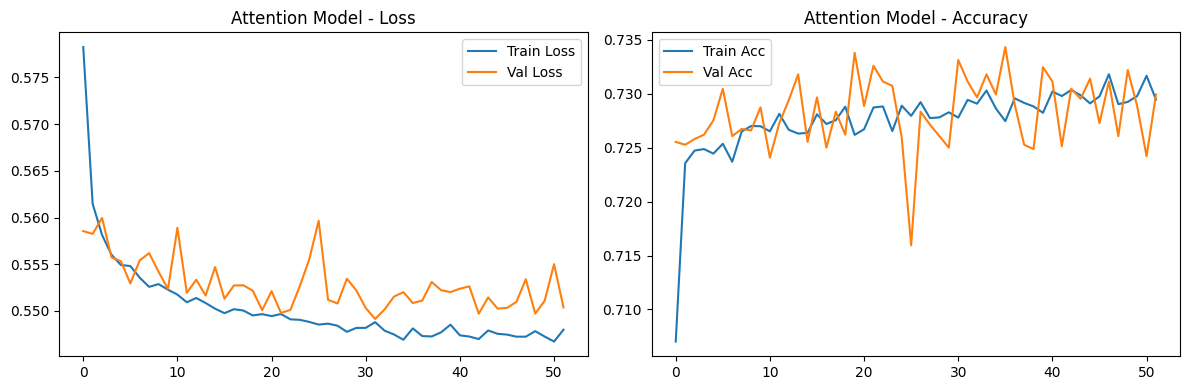

In [47]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Attention Model - Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Attention Model - Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
y_prob_attn = attention_model.predict(X_test).flatten()
y_pred_attn = (y_prob_attn >= 0.5).astype(int)

print('=== Attention Neural Network Results ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_attn):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_attn):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_attn):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_attn):.4f}')
print(f'AUC      : {roc_auc_score(y_test, y_prob_attn):.4f}')
print(classification_report(y_test, y_pred_attn))

  1/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step
=== Attention Neural Network Results ===
Accuracy : 0.7242
Precision: 0.7748
Recall   : 0.6225
F1 Score : 0.6904
AUC      : 0.7906
              precision    recall  f1-score   support

           0       0.69      0.82      0.75      6328
           1       0.77      0.62      0.69      6175

    accuracy                           0.72     12503
   macro avg       0.73      0.72      0.72     12503
weighted avg       0.73      0.72      0.72     12503



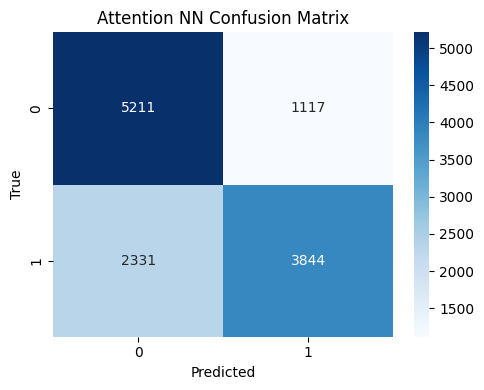

In [51]:
cm_attn = confusion_matrix(y_test, y_pred_attn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_attn, annot=True, fmt='d', cmap='Blues')
plt.title('Attention NN Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

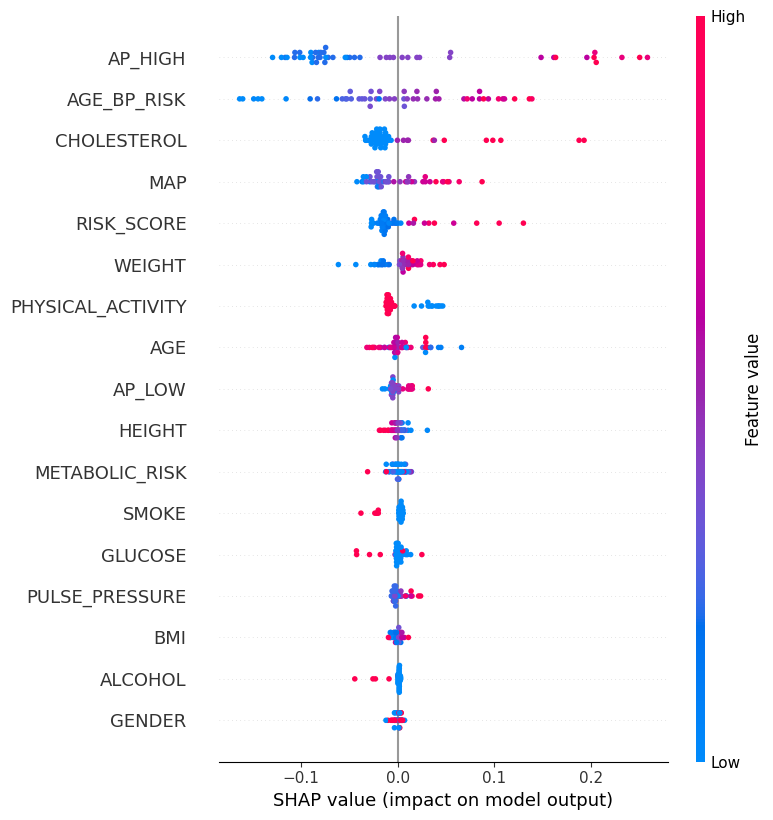

In [54]:
# ============================================================
# EXPLAINABILITY - Attention NN  (use SHAP DeepExplainer)
# ============================================================

# 1) SHAP - Attention NN
background = X_train[:]
explainer_attn = shap.DeepExplainer(attention_model, background)
shap_values_attn_raw = explainer_attn.shap_values(X_test[:50])

# Normalize output format across SHAP versions
if isinstance(shap_values_attn_raw, list):
    shap_values_attn = shap_values_attn_raw[0]          # list[array(n,f)]
elif shap_values_attn_raw.ndim == 3:
    shap_values_attn = shap_values_attn_raw[:, :, 0]    # (n,f,1) -> (n,f)
else:
    shap_values_attn = shap_values_attn_raw              # (n,f)

# Normalize expected_value to scalar
ev_attn = explainer_attn.expected_value
if hasattr(ev_attn, '__len__'):
    ev_attn = float(ev_attn[0])
else:
    ev_attn = float(ev_attn)

shap.summary_plot(shap_values_attn, X_test[:50], feature_names=feature_names, show=True)

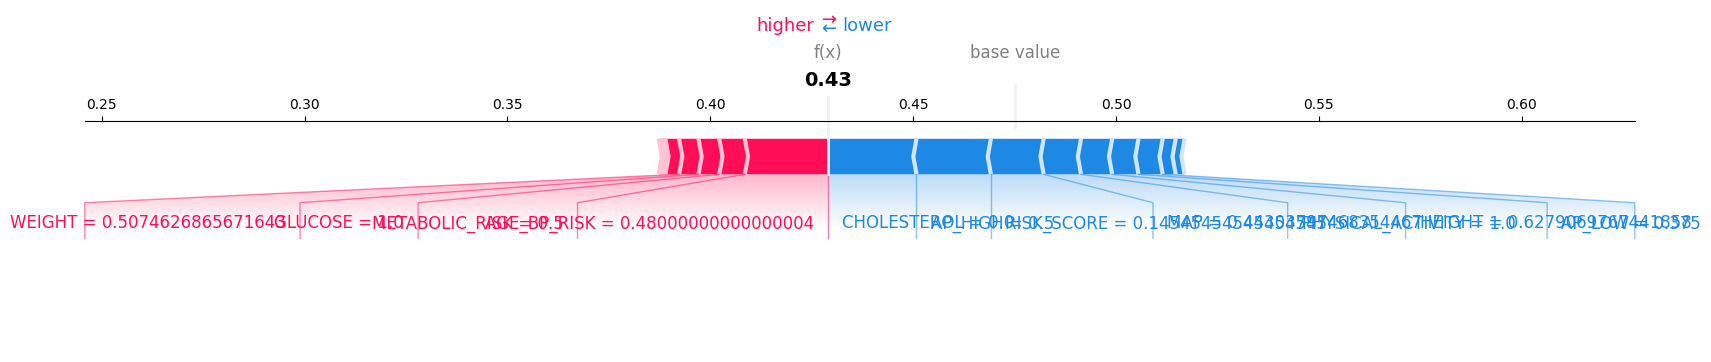

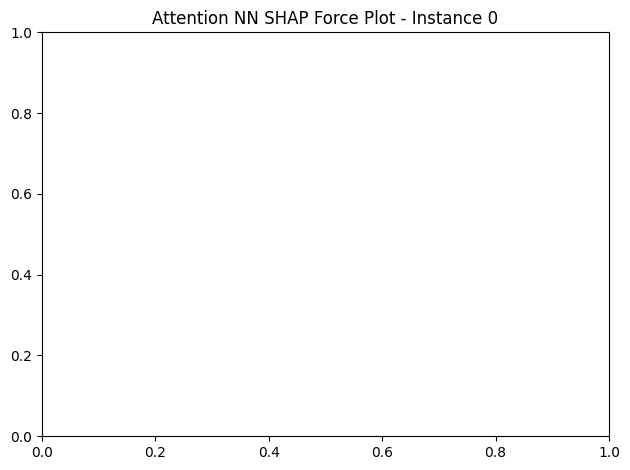

In [55]:
shap.force_plot(
    ev_attn,
    shap_values_attn[0],
    X_test[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.title('Attention NN SHAP Force Plot - Instance 0')
plt.tight_layout()
plt.show()

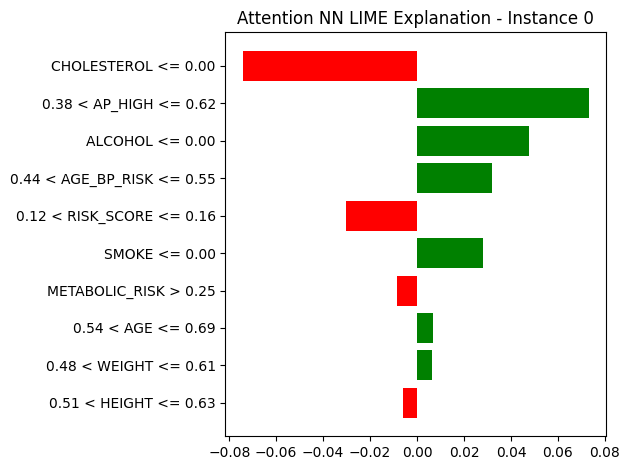

In [56]:
# 2) LIME - Attention NN
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification',
    random_state=42
)

def attn_predict(x):
    p = attention_model.predict(x, verbose=0).flatten()
    return np.column_stack([1-p, p])

lime_exp_attn = lime_explainer.explain_instance(X_test[0], attn_predict, num_features=10)
lime_exp_attn.as_pyplot_figure()
plt.title('Attention NN LIME Explanation - Instance 0')
plt.tight_layout()
plt.show()

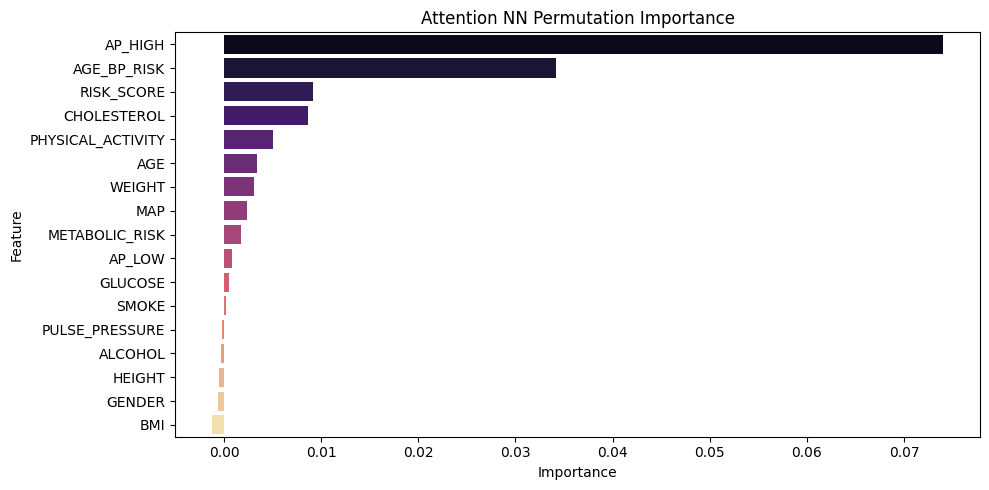

In [57]:
# 4) Permutation Importance - Attention NN
from sklearn.metrics import make_scorer

def keras_predict(X):
    return (attention_model.predict(X, verbose=0).flatten() >= 0.5).astype(int)

perm_scores = []
base_acc = accuracy_score(y_test, keras_predict(X_test))

for i, feat in enumerate(feature_names):
    X_perm = X_test.copy()
    X_perm[:, i] = np.random.permutation(X_perm[:, i])
    perm_acc = accuracy_score(y_test, keras_predict(X_perm))
    perm_scores.append(base_acc - perm_acc)

perm_attn_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_scores}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=perm_attn_df, x='Importance', y='Feature', palette='magma')
plt.title('Attention NN Permutation Importance')
plt.tight_layout()
plt.show()

In [58]:
# Final comparison table
results = pd.DataFrame({
    'Model'    : ['Attention NN'],
    'Accuracy' : [accuracy_score(y_test, y_pred_attn)],
    'Precision': [precision_score(y_test, y_pred_attn)],
    'Recall'   : [recall_score(y_test, y_pred_attn)],
    'F1'       : [f1_score(y_test, y_pred_attn)],
    'AUC'      : [roc_auc_score(y_test, y_prob_attn)]
})
print(results.to_string(index=False))

       Model  Accuracy  Precision  Recall       F1      AUC
Attention NN  0.724226   0.774844 0.62251 0.690374 0.790616
